#### Importing the required packages

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

#### Loading the dataset

In [5]:
df = pd.read_csv("../data/marine_risk_processed.csv")
df.head()

,datetime,wind_speed_kts,wind_direction_deg,air_temperature_c,water_temperature_c,relative_humidity_pct,air_pressure_hpa,station_name,latitude,longitude,risk_class,risk_label,wave_height_m,wave_period_s
0,2020-01-01 12:00:00,NaN,NaN,25.3,NaN,66.6,1014.5,arabian_sea_15n65e,15.0,65.0,0,LOW,0.843357,6.377153
1,2020-01-02 12:00:00,NaN,NaN,25.2,NaN,66.3,1016.1,arabian_sea_15n65e,15.0,65.0,0,LOW,0.845298,5.555953
2,2020-01-03 12:00:00,NaN,NaN,25.2,NaN,65.2,1015.8,arabian_sea_15n65e,15.0,65.0,0,LOW,1.238599,5.327560
3,2020-01-04 12:00:00,NaN,NaN,25.1,NaN,64.2,1014.3,arabian_sea_15n65e,15.0,65.0,0,LOW,1.245345,5.690114
4,2020-01-05 12:00:00,NaN,NaN,25.1,NaN,59.8,1012.8,arabian_sea_15n65e,15.0,65.0,0,LOW,1.034001,6.324389


#### Understanding the Dataset

In [6]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape: (4028, 14)

Column names:
Index(['datetime', 'wind_speed_kts', 'wind_direction_deg', 'air_temperature_c',
       'water_temperature_c', 'relative_humidity_pct', 'air_pressure_hpa',
       'station_name', 'latitude', 'longitude', 'risk_class', 'risk_label',
       'wave_height_m', 'wave_period_s'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4028 entries, 0 to 4027
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   datetime               4028 non-null   object 
 1   wind_speed_kts         3734 non-null   float64
 2   wind_direction_deg     3734 non-null   float64
 3   air_temperature_c      4018 non-null   float64
 4   water_temperature_c    3111 non-null   float64
 5   relative_humidity_pct  3942 non-null   float64
 6   air_pressure_hpa       1381 non-null   float64
 7   station_name           4028 non-null   object 
 8   latitude          

#### Checking missing values

In [7]:
df.isnull().sum()

datetime                    0
wind_speed_kts            294
wind_direction_deg        294
air_temperature_c          10
water_temperature_c       917
relative_humidity_pct      86
air_pressure_hpa         2647
station_name                0
latitude                    0
longitude                   0
risk_class                  0
risk_label                  0
wave_height_m               0
wave_period_s               0
dtype: int64

#### Visualizing the dataset on the basis of Risk Class Classification

risk_class
0    1967
1    1840
2     191
3      30
Name: count, dtype: int64


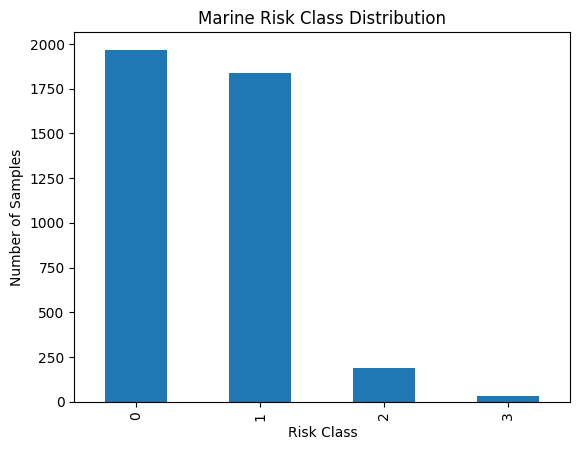

In [8]:
print(df["risk_class"].value_counts())

df["risk_class"].value_counts().plot(
    kind="bar"
)

plt.title("Marine Risk Class Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of Samples")

plt.show()

#### Process Datetime

In [9]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["week"] = df["datetime"].dt.isocalendar().week
df.drop("datetime", axis=1)
df.head()

,datetime,wind_speed_kts,wind_direction_deg,air_temperature_c,water_temperature_c,relative_humidity_pct,air_pressure_hpa,station_name,latitude,longitude,risk_class,risk_label,wave_height_m,wave_period_s,month,day,week
0,2020-01-01 12:00:00,NaN,NaN,25.3,NaN,66.6,1014.5,arabian_sea_15n65e,15.0,65.0,0,LOW,0.843357,6.377153,1,1,1
1,2020-01-02 12:00:00,NaN,NaN,25.2,NaN,66.3,1016.1,arabian_sea_15n65e,15.0,65.0,0,LOW,0.845298,5.555953,1,2,1
2,2020-01-03 12:00:00,NaN,NaN,25.2,NaN,65.2,1015.8,arabian_sea_15n65e,15.0,65.0,0,LOW,1.238599,5.327560,1,3,1
3,2020-01-04 12:00:00,NaN,NaN,25.1,NaN,64.2,1014.3,arabian_sea_15n65e,15.0,65.0,0,LOW,1.245345,5.690114,1,4,1
4,2020-01-05 12:00:00,NaN,NaN,25.1,NaN,59.8,1012.8,arabian_sea_15n65e,15.0,65.0,0,LOW,1.034001,6.324389,1,5,1


#### Seperate Input/Target

In [10]:
X = df.drop(columns = ["risk_class", "risk_label"])
y = df["risk_class"]

#### Define Column Type

In [39]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

#### Preprocessing

In [40]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#### Train/Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#### XGBoost Model

In [20]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class = 4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

#### Create Full Pipeline

In [21]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ]
)

#### Train

In [22]:
print("\nTraining XGBoost model...")
pipeline.fit(X_train, y_train)


Training XGBoost model...


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Predict

In [23]:
y_pred = pipeline.predict(X_test)

#### Evaluate

In [32]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "LOW",
            "MODERATE",
            "HIGH",
            "EXTREME"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9925558312655087

Classification Report:
              precision    recall  f1-score   support

         LOW       1.00      0.99      1.00       394
    MODERATE       0.99      0.99      0.99       368
        HIGH       0.93      0.97      0.95        38
     EXTREME       0.83      0.83      0.83         6

    accuracy                           0.99       806
   macro avg       0.94      0.95      0.94       806
weighted avg       0.99      0.99      0.99       806


Confusion Matrix:
[[392   2   0   0]
 [  0 366   2   0]
 [  0   0  37   1]
 [  0   0   1   5]]


#### Checking feature importance

In [30]:
# Get the trained XGBoost model
xgb_model = pipeline.named_steps["classifier"]

# Get feature importance
importance = xgb_model.feature_importances_

# Get transformed feature names
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                                   Feature  Importance
8                       num__wave_height_m    0.545605
5                    num__air_pressure_hpa    0.091795
1                  num__wind_direction_deg    0.085688
0                      num__wind_speed_kts    0.049244
15   cat__station_name_bay_of_bengal_8n90e    0.028639
12     cat__station_name_arabian_sea_8n67e    0.028471
9                       num__wave_period_s    0.023125
14  cat__station_name_bay_of_bengal_15n90e    0.021500
7                           num__longitude    0.020420
6                            num__latitude    0.018478
4               num__relative_humidity_pct    0.016275
11     cat__station_name_arabian_sea_4n67e    0.015762
3                 num__water_temperature_c    0.015108
10    cat__station_name_arabian_sea_15n65e    0.014375
2                   num__air_temperature_c    0.012959


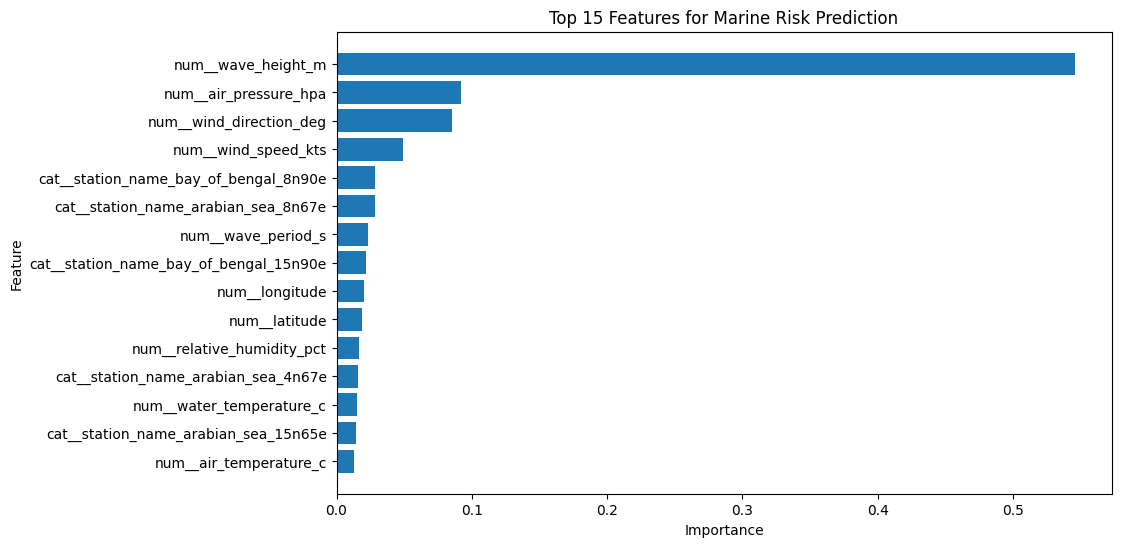

In [31]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Marine Risk Prediction")
plt.gca().invert_yaxis()
plt.show()

In [33]:
# Check average wave height for each risk class

df.groupby("risk_label")["wave_height_m"].agg(
    ["count", "min", "max", "mean", "median", "std"]
)

,count,min,max,mean,median,std
risk_label,,,,,,
EXTREME,30,4.036887,6.632256,4.551482,4.316140,0.601220
HIGH,191,2.195869,3.999459,3.183413,3.134468,0.321360
LOW,1967,0.514969,1.498447,1.166889,1.177881,0.193587
MODERATE,1840,0.763932,2.796365,1.955329,1.894847,0.373512


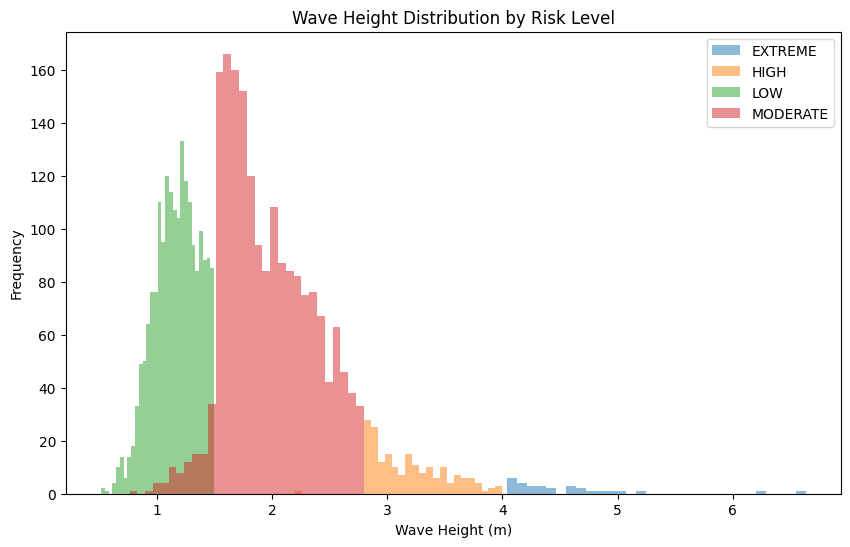

In [34]:
# See wave height distribution for each risk class

plt.figure(figsize=(10, 6))

for risk in sorted(df["risk_label"].unique()):
    data = df[df["risk_label"] == risk]["wave_height_m"].dropna()

    plt.hist(
        data,
        bins=30,
        alpha=0.5,
        label=risk
    )

plt.xlabel("Wave Height (m)")
plt.ylabel("Frequency")
plt.title("Wave Height Distribution by Risk Level")
plt.legend()

plt.show()

#### Experimenting without wave_height_m

In [35]:
df_no_wave = df.copy()

In [42]:
X_no_wave = df_no_wave.drop(
    columns=[
        "risk_class",
        "risk_label",
        "wave_height_m"
    ]
)

y = df_no_wave["risk_class"]

In [43]:
numerical_features = X_no_wave.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_no_wave.select_dtypes(
    include=["object"]
).columns.tolist()

In [44]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [46]:
X_train_nw, X_test_nw, y_train_nw, y_test_nw = train_test_split(
    X_no_wave,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class = 4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

In [48]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ]
)

In [50]:
print("\nTraining XGBoost model...")
pipeline.fit(X_train_nw, y_train_nw)


Training XGBoost model...


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
y_pred = pipeline.predict(X_test_nw)

In [52]:
accuracy = accuracy_score(y_test_nw, y_pred)
print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test_nw,
        y_pred,
        target_names=[
            "LOW",
            "MODERATE",
            "HIGH",
            "EXTREME"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_nw, y_pred))


Accuracy: 0.869727047146402

Classification Report:
              precision    recall  f1-score   support

         LOW       0.89      0.93      0.91       394
    MODERATE       0.87      0.86      0.86       368
        HIGH       0.60      0.47      0.53        38
     EXTREME       0.67      0.33      0.44         6

    accuracy                           0.87       806
   macro avg       0.76      0.65      0.69       806
weighted avg       0.87      0.87      0.87       806


Confusion Matrix:
[[366  28   0   0]
 [ 44 315   9   0]
 [  0  19  18   1]
 [  0   1   3   2]]
